# I. Import libraries 

In [ ]:
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START, StateGraph, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_core.tools import Tool
from langchain_community.tools import DuckDuckGoSearchRun, DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_groq import ChatGroq

from huggingface_hub import list_models
from typing import List, TypedDict, Optional, Annotated, Literal
import random
from datasets import load_dataset
import pandas as pd
from IPython.display import Image, display
from pydantic import BaseModel, Field
import json
from ddgs import DDGS
from html import escape
from datetime import datetime
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.header import Header
from email.message import EmailMessage

/home/thomas/Desktop/AI/Agent/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model="llama-3.1-8b-instant", max_tokens=1000)

# II. Model

In [4]:
class DigestState(TypedDict):
    user_id: str
    run_date: str
    topics: list[str]
    max_articles_per_topic: int
    output_language: str
    digest_style: str
    user_interests: list[str]
    src_url: list[str]

    queries: list[str]
    candidate_urls: list[dict]
    fetched_docs: list[dict]
    filtered_docs: list[dict]
    summarized_docs: list[dict]

    email_subject: str
    email_markdown: str
    email_html: str
    warnings: list[str]

In [5]:
class SearchQueries(BaseModel):
    queries: list[str] = Field(default_factory = list, description = "List of search queries to find relevant news articles. Each query should be a concise phrase or keyword related to the user's interests or specified topics. The queries will be used to retrieve news articles from various sources, so they should be specific enough to yield relevant results while broad enough to capture a range of related articles.")


In [6]:
class FilterDocsInput(BaseModel):
    selected_indices: List[int] = Field(
        default_factory=list,
        description="The index list includes articles with a relevance rating of 7/10 or higher."
    )

In [7]:
class ScoreOutput(BaseModel):
    analysis: str = Field(
        description="A brief analysis of how the article content relates to the user's specific interests."
    )
    score: int = Field(
        description="A relevance score on a scale of 1 to 10."
    )

# III. Nodes

In [ ]:
def load_profile(state: DigestState) -> dict:
    topics = state["topics"] or ["RAG"]
    max_articles = state["max_articles_per_topic"] or 2

    return {
        "topics": topics,
        "max_articles": max_articles
    }

def generate_queries(state: DigestState) -> dict:
    topics = state["topics"]
    prompt = f"""
        Role: 
        You are an planner expert. 

        Task: 
        Generate exactly 2 search queries for the given topics 

        Topics:
        {topics}

        Rules: 
        -  One general query
        - One more specific or technical query
        - Each query must be short
        - Include one keyword: latest, news, update, or release notes
        - Do not generate more than 2 queries

        OutputJson:
        {{
            "queries": ["...", "..."]
        }}

    """

    llm_with_tool = llm.with_structured_output(SearchQueries)
    response = llm_with_tool.invoke(prompt)

    return {
        "queries": response.queries
    }
    
def web_search(state: DigestState) -> dict:
    queries = state["queries"]
    results = []

    search = DDGS()
    for query in queries:
        search_results = list(search.text(query, max_results=state["max_articles_per_topic"]))

        results.append({
            "query": query,
            "results": search_results
        })

    return {"candidate_urls": results}

def filter_docs(state: DigestState) -> dict: 
    
    candidate_urls = state["candidate_urls"]
    filtered_results = []
    llm_with_tool = llm.with_structured_output(ScoreOutput)
    for candidate in candidate_urls:
        query = candidate["query"]
        results = candidate["results"]
        for result in results:
            title = result["title"]
            body = result["body"]

            
            content_snippet = body[:1200] 

            prompt = f"""
                Role: Professional News Analyst
                Task: Evaluate the relevance of the news article below to the user's specific interests.
                
                User Interests: {state.get('user_interests', 'General Technology and AI')}
                Search Context: This article was found using the query "{query}".

                Article Title: {title}
                Article Content: {content_snippet}

                Rules:
                1. Analyze the relationship between the article and the User Interests.
                2. Provide a relevance score from 1 (irrelevant) to 10 (perfect match).
                3. High scores (7+) should be reserved for articles that directly impact or provide deep insight into the user's topics.
                4. Focus only on content relevance, ignoring writing style or source.
            """

            try: 
                response = llm_with_tool.invoke(prompt)
                if response.score >=7: 
                    filtered_results.append({
                        "query": query,
                        "title": title,
                        "body": body,
                        "src_url": result["href"],
                        "analysis": response.analysis,
                        "score": response.score
                    })
            except Exception as e:
                raise RuntimeError(f"Error scoring document relevance: {e}")

    return {
        "filtered_docs": filtered_results
    }

def summarize_with_llm(state: DigestState) -> dict:
    docs = state["filtered_docs"]
    summaries = []
    for doc in docs:
        prompt = f"""
        Summarize the following content for a morning email digest.

        Rules:
        - Maximum 3 bullet points
        - Each bullet must be one short sentence
        - Focus only on what is new or important
        - No introduction like "Here's a summary"
        - No repetition
        - Keep it compact and professional

        Content:
        {doc['body']}
        """ 
        summary = llm.invoke(prompt)

        summary_text = summary.content if hasattr(summary, "content") else str(summary)

        summaries.append({
            "query": doc["query"],
            "title": doc["title"],
            "summary": summary_text,
            "src_url": doc["src_url"]
        })
    return {"summarized_docs": summaries}

def convert_to_markdown(state: DigestState) -> dict:
    summarizes = state["summarized_docs"]

    lines = ["# Morning Digest", ""]
    
    for item in summarizes:
        lines.append(f"## {item['query']}")
        lines.append(f"### {item['title']}")
        lines.append(f"{item['summary']}")
        lines.append(f"[Read more]({item['src_url']})")
        lines.append("")
    
    markdown = "\n".join(lines).strip() or "# Morning Digest\n\nNo content available."
    return {
        "email_markdown": markdown,
    }


def render_bullets(summary_text: str) -> str:
    lines = str(summary_text).split("\n")
    items = []

    for line in lines:
        cleaned = line.strip().lstrip("-*+ ").strip()
        if cleaned:
            items.append(
                f"<li style='margin-bottom:10px; color:#374151; line-height:1.65;'>{escape(cleaned)}</li>"
            )

    if not items:
        return "<p style='color:#6b7280;'>No summary available.</p>"

    return f"<ul style='padding-left:20px; margin:12px 0 0 0;'>{''.join(items)}</ul>"


def build_email_html(summaries, topics=None):
    today = datetime.now().strftime("%d %b %Y")
    topic_text = ", ".join(topics or [])

    html_parts = [
        """
        <html>
          <body style="margin:0; padding:0; background:#f3f4f6; font-family: Inter, Arial, Helvetica, sans-serif;">
            <div style="max-width:760px; margin:0 auto; padding:32px 20px;">
              <div style="background:#111827; color:white; padding:28px 32px; border-radius:18px 18px 0 0;">
                <div style="font-size:13px; letter-spacing:0.08em; text-transform:uppercase; opacity:0.75;">
                  Personalized Morning Research Agent
                </div>
                <h1 style="margin:10px 0 8px 0; font-size:30px; line-height:1.2;">
                  Morning Digest
                </h1>
        """
    ]

    html_parts.append(
        f"""
                <p style="margin:0; font-size:15px; color:#d1d5db;">
                  Daily brief for <strong>{escape(topic_text) if topic_text else 'your selected topics'}</strong>
                </p>
              </div>

              <div style="background:white; padding:28px 32px; border-radius:0 0 18px 18px; box-shadow:0 10px 30px rgba(0,0,0,0.06);">
                <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:18px; flex-wrap:wrap; gap:8px;">
                  <div style="font-size:14px; color:#6b7280;">{today}</div>
                  <div style="font-size:13px; color:#9ca3af;">Auto-generated research summary</div>
                </div>

                <div style="margin-bottom:24px; padding:16px 18px; background:#f9fafb; border:1px solid #e5e7eb; border-radius:12px;">
                  <div style="font-size:14px; color:#374151; line-height:1.7;">
                    Curated highlights from web sources, summarized into a compact morning brief.
                  </div>
                </div>
        """
    )

    for idx, item in enumerate(summaries, start=1):
        query = escape(str(item.get("query", "Untitled Topic")))
        title = escape(str(item.get("title", "No Title")))
        source_url = escape(str(item.get("src_url", "#")))
        summary_text = item.get("summary", "")
        if hasattr(summary_text, "content"):
            summary_text = summary_text.content

        bullets_html = render_bullets(summary_text)

        html_parts.append(
            f"""
                <div style="margin-top:26px; border:1px solid #e5e7eb; border-radius:16px; overflow:hidden;">
                  <div style="padding:16px 20px; background:#fafafa; border-bottom:1px solid #e5e7eb;">
                    <div style="font-size:12px; color:#9ca3af; text-transform:uppercase; letter-spacing:0.08em;">
                      Topic: {idx}
                    </div>
                    <h2 style="margin:8px 0 0 0; font-size:22px; color:#111827; line-height:1.3;">
                      {query}
                    </h2>
                    <p style="margin:6px 0 0 0; font-size:14px; color:#6b7280;">
                      {title}
                    </p>

                  </div>

                  <div style="padding:18px 20px 20px 20px;">
                    {bullets_html}

                    <div style="margin-top:18px;">
                      <a href="{source_url}"
                         style="display:inline-block; padding:10px 14px; background:#111827; color:#ffffff; text-decoration:none; border-radius:10px; font-size:14px; font-weight:600;">
                        Read source
                      </a>
                    </div>
                  </div>
                </div>
            """
        )

    html_parts.append(
        """
                <div style="margin-top:30px; padding-top:18px; border-top:1px solid #e5e7eb;">
                  <p style="margin:0; font-size:12px; color:#9ca3af; line-height:1.7;">
                    Generated by your AI research workflow using LangGraph + FastAPI.
                  </p>
                </div>
              </div>
            </div>
          </body>
        </html>
        """
    )

    return "".join(html_parts)


def format_email(state: DigestState) -> dict:
    topics = state.get("topics", [])
    subject = f"Morning Digest | {', '.join(topics)}"

    html_body = build_email_html(
        summaries=state.get("summarized_docs", []),
        topics=topics
    )

    return {
        "email_subject": subject,
        "email_html": html_body,
        "email_markdown": state.get("email_markdown", "")
    }

def clean_text(text: str) -> str:
    if not text:
        return ""
    return (
        str(text)
        .replace("\xa0", " ")
        .replace("\u200b", "")
        .strip()
    )

def send_email(state: DigestState):
    # 1. Thông tin cấu hình (Nên để trong biến môi trường .env)
    sender_email = os.environ.get("MAIL_SENDER")
    receiver_email = os.environ.get("MAIL_RECEIVER")
    password = os.environ.get("MAIL_PASSWORD")

    # 2. Lấy nội dung từ State
    subject = clean_text(state["email_subject"])
    plain_body = clean_text(state["email_markdown"])
    html_body = state["email_html"]


    # 3. Tạo cấu trúc Email
    message = EmailMessage()
    message["From"] = sender_email
    message["To"] = receiver_email
    message["Subject"] = str(Header(subject, "utf-8")) # Đảm bảo tiêu đề được mã hóa đúng
    # message.attach(MIMEText(body, "plain", "utf-8")) # Gửi dạng text/markdown
    message.set_content(plain_body, subtype="plain", charset="utf-8") # Sử dụng set_content để đảm bảo mã hóa đúng và gửi dưới dạng plain text
    message.add_alternative(html_body, subtype="html", charset="utf-8") # Thêm phần HTML

    # 4. Thực hiện gửi
    try:
        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
            server.login(sender_email, password)
            server.send_message(message)
        print("✅ Email đã được gửi thành công!")
    except Exception as e:
        print(f"❌ Lỗi khi gửi email: {e}")

    return state # Trả về state nguyên vẹn vì đây là bước cuối

SyntaxError: unmatched ')' (753919912.py, line 299)

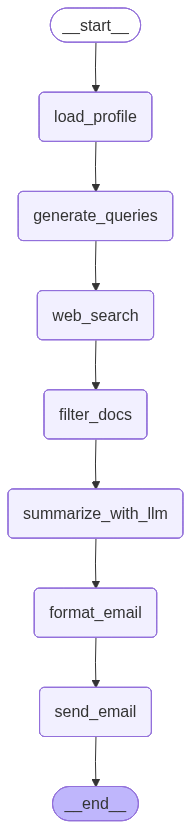

In [ ]:
def build_graph():
    builder = StateGraph(DigestState)

    builder.add_node("load_profile", load_profile)
    builder.add_node("generate_queries", generate_queries)
    builder.add_node("web_search", web_search)
    builder.add_node("filter_docs", filter_docs)
    builder.add_node("summarize_with_llm", summarize_with_llm)
    builder.add_node("format_email", format_email)
    builder.add_node("send_email", send_email)


    builder.add_edge(START, "load_profile")
    builder.add_edge("load_profile", "generate_queries")
    builder.add_edge("generate_queries", "web_search")
    builder.add_edge("web_search", "filter_docs")
    builder.add_edge("filter_docs", "summarize_with_llm")


    builder.add_edge("summarize_with_llm", "format_email")
    builder.add_edge("format_email", "send_email")
    builder.add_edge("send_email", END)

    return builder.compile()


graph = build_graph()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
initial_state = {
    "user_id": "quy",
    "run_date": "2026-04-21",
    "topics": ["Computer Vision"],
    "max_articles_per_topic": 3,
    "user_interests":["CNN", "YoLo"], 
    "output_language": "vi",
    "digest_style": "brief",

    "queries": [],
    "candidate_urls": [],
    "fetched_docs": [],
    "filtered_docs": [],
    "summarized_docs": [],


    "email_subject": "",
    "email_markdown": "",
    "warnings": [],
}

In [ ]:
result = graph.invoke(initial_state)

✅ Email đã được gửi thành công!
